# 作业二

## 2 多层感知机
### 2.1 理论计算题

**1. 非线性激活函数的重要性证明**

给定隐藏层无激活函数的 MLP：

$$h = W_1 x + b_1$$
$$o = W_2 h + b_2$$

代入 h：

$$o = W_2 (W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2)$$

令 $W' = W_2 W_1$，$b' = W_2 b_1 + b_2$，则：

$$o = W' x + b'$$

该网络等价于一个单层神经网络，权重矩阵 $W' = W_2 W_1$，偏置向量 $b' = W_2 b_1 + b_2$。
这说明没有非线性激活函数，无论多少层，最终都等价于一个线性变换。

**2. Sigmoid 与 tanh 的导数**

**Sigmoid 函数：**

$$\text{Sigmoid}(x) = \frac{1}{1 + e^{-x}}$$

求导：

$$\text{Sigmoid}'(x) = \frac{e^{-x}}{(1 + e^{-x})^2} = \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} = \text{Sigmoid}(x) \cdot (1 - \text{Sigmoid}(x))$$

**tanh 函数：**

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

求导：

$$\tanh'(x) = 1 - \tanh^2(x)$$

两者都可以表示为自身函数的简单多项式，这使得反向传播计算变简便。

### 2.2 编程题

从零实现一个多分类单隐藏层 MLP，在 Fashion-MNIST 上训练。

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# 加载 Fashion-MNIST 数据集
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

X_train = train_dataset.data.float() / 255.0
X_train = X_train.reshape(-1, 28 * 28)
y_train = train_dataset.targets

X_test = test_dataset.data.float() / 255.0
X_test = X_test.reshape(-1, 28 * 28)
y_test = test_dataset.targets

print(f'训练集大小: {X_train.shape[0]}, 特征维度: {X_train.shape[1]}')
print(f'测试集大小: {X_test.shape[0]}')

# One-hot 编码
num_classes = 10
Y_train = torch.eye(num_classes)[y_train]
Y_test = torch.eye(num_classes)[y_test]

训练集大小: 60000, 特征维度: 784
测试集大小: 10000


In [2]:
# 1. 手动初始化参数（正态分布随机初始化）
input_dim = 784
hidden_dim = 256
output_dim = 10

W1 = torch.randn(input_dim, hidden_dim) * 0.01
b1 = torch.zeros(hidden_dim)
W2 = torch.randn(hidden_dim, output_dim) * 0.01
b2 = torch.zeros(output_dim)

print(f'W1 shape: {W1.shape}, b1 shape: {b1.shape}')
print(f'W2 shape: {W2.shape}, b2 shape: {b2.shape}')

W1 shape: torch.Size([784, 256]), b1 shape: torch.Size([256])
W2 shape: torch.Size([256, 10]), b2 shape: torch.Size([10])


In [3]:
# 2. ReLU 激活函数
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# ReLU 反向传播用到的梯度由 max(0, x) 直接处理，在 backward 中实现

# 3. Softmax + 交叉熵损失
def softmax(logits):
    shifted = logits - logits.max(dim=1, keepdim=True).values
    exp_vals = torch.exp(shifted)
    return exp_vals / exp_vals.sum(dim=1, keepdim=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = torch.clamp(y_pred, eps, 1.0 - eps)
    return -torch.mean(torch.sum(y_true * torch.log(y_pred), dim=1))

In [4]:
# 4. 小批量随机梯度下降训练
learning_rate = 0.1
batch_size = 64
epochs = 30
train_losses = []
test_accuracies = []

for epoch in range(epochs):
    # 打乱训练数据
    indices = torch.randperm(X_train.shape[0])
    X_shuffled = X_train[indices]
    Y_shuffled = Y_train[indices]
    
    total_loss = 0.0
    num_batches = 0
    
    for start in range(0, X_train.shape[0], batch_size):
        end = min(start + batch_size, X_train.shape[0])
        xb = X_shuffled[start:end]
        yb = Y_shuffled[start:end]
        
        # ---- 前向传播 ----
        h = relu(xb @ W1 + b1)
        logits = h @ W2 + b2
        probs = softmax(logits)
        loss = cross_entropy(yb, probs)
        
        total_loss += loss.item()
        num_batches += 1
        
        # ---- 反向传播（手动求导）----
        bs = xb.shape[0]
        
        # dL/dlogits = (probs - y_true) / batch_size
        d_logits = (probs - yb) / bs
        
        # dL/dW2 = h^T @ d_logits
        d_W2 = h.T @ d_logits
        # dL/db2 = sum(d_logits)
        d_b2 = d_logits.sum(dim=0)
        
        # dL/dh = d_logits @ W2^T
        d_h = d_logits @ W2.T
        # ReLU 反向传播: dx = d_out if x > 0 else 0
        d_h[h <= 0] = 0
        
        # dL/dW1 = xb^T @ d_h
        d_W1 = xb.T @ d_h
        # dL/db1 = sum(d_h)
        d_b1 = d_h.sum(dim=0)
        
        # ---- 参数更新 ----
        W1 -= learning_rate * d_W1
        b1 -= learning_rate * d_b1
        W2 -= learning_rate * d_W2
        b2 -= learning_rate * d_b2
    
    avg_loss = total_loss / num_batches
    train_losses.append(avg_loss)
    
    # 测试集评估
    with torch.no_grad():
        h_test = relu(X_test @ W1 + b1)
        test_probs = softmax(h_test @ W2 + b2)
        test_preds = torch.argmax(test_probs, dim=1)
        acc = (test_preds == y_test).float().mean().item()
        test_accuracies.append(acc)
    
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f'Epoch {epoch:3d}, Loss: {avg_loss:.4f}, Test Accuracy: {acc:.4f}')

Epoch   0, Loss: 0.6863, Test Accuracy: 0.8068


Epoch   5, Loss: 0.3354, Test Accuracy: 0.8510


Epoch  10, Loss: 0.2823, Test Accuracy: 0.8760


Epoch  15, Loss: 0.2498, Test Accuracy: 0.8667


Epoch  20, Loss: 0.2256, Test Accuracy: 0.8839


Epoch  25, Loss: 0.2044, Test Accuracy: 0.8869


Epoch  29, Loss: 0.1902, Test Accuracy: 0.8891


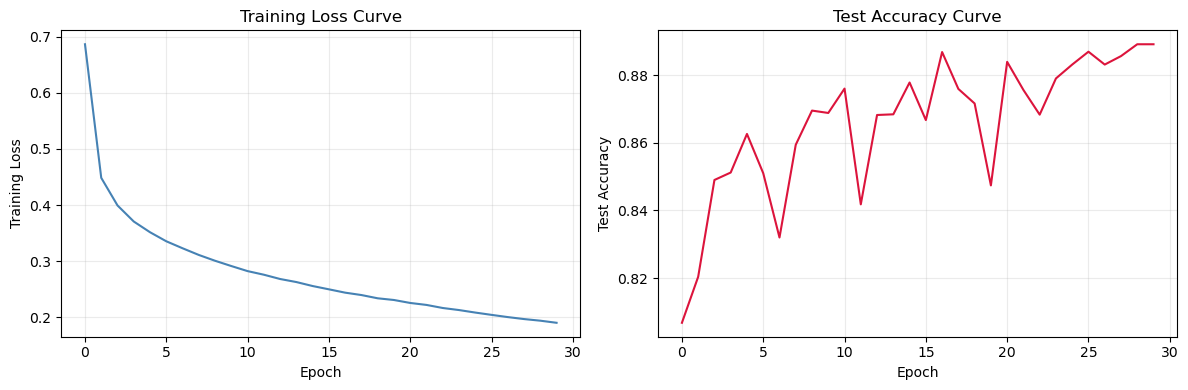

最终测试集准确率: 0.8891


In [5]:
# 绘制训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Curve')
ax1.grid(alpha=0.25)

ax2.plot(test_accuracies, color='crimson')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy Curve')
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'最终测试集准确率: {test_accuracies[-1]:.4f}')

## 3 模型选择，权重衰减和丢弃法
### 3.1 理论计算题

**1. 过拟合与欠拟合**

- **训练误差（Training Error）**：模型在训练集上的误差，衡量模型对训练数据的拟合程度。
- **泛化误差（Generalization Error）**：模型在未见过的新数据上的期望误差，衡量模型真正的预测能力。

当训练误差极低但泛化误差很高时，模型处于**过拟合**状态：模型过度记忆了训练数据中的噪声和细节，而没能学到数据背后的通用模式。

缓解方法：
1. **降低模型复杂度**：减少网络层数或神经元数量；
2. **增加训练数据**：更多的数据让模型难以过拟合个别模式；
3. **正则化**：L1/L2 权重衰减、Dropout 等方法限制模型容量；
4. **早停（Early Stopping）**：在验证误差开始上升时停止训练。

**2. K 折交叉验证**

K 折交叉验证的具体实施步骤：

1. 将数据集随机等分为 K 个子集（折），保持每折中类别分布尽量一致（分层抽样）；
2. 对于 $i = 1, 2, \ldots, K$：
   - 将第 $i$ 折作为验证集；
   - 将剩余 $K-1$ 折合并作为训练集；
   - 训练模型并在验证集上评估，记录性能指标（如准确率）；
3. 计算 K 次评估结果的平均值和标准差，作为模型性能的最终估计。

常用取值：$K=5$ 或 $K=10$。特别地，当 $K=n$（样本总数）时为留一交叉验证（LOOCV）。

### 3.2 编程题

在 MLP 上加入 L2 正则化（权重衰减）和 Dropout，并对比效果。

In [6]:
import zhplot
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1. 带权重衰减的 SGD 优化器
# ==========================================
def sgd_update(param, grad, lr, weight_decay=0.0):
    """带权重衰减的参数更新（in-place）"""
    param *= (1 - lr * weight_decay)  # 权重衰减
    param -= lr * grad                  # 梯度更新

In [7]:
# ==========================================
# 2. 从零实现 Dropout 层
# ==========================================
def dropout_layer(X, dropout, is_training=True):
    """
    Dropout 层。训练时随机丢弃神经元，推理时直接返回输入。
    返回 (output, mask) 以便反向传播时复用 mask。
    
    参数：
        X: 输入张量
        dropout: 丢弃概率
        is_training: 是否为训练模式
    """
    if not is_training or dropout == 0.0:
        return X, torch.ones_like(X)
    mask = (torch.rand_like(X) > dropout).float()
    # 缩放以保持期望值不变；返回 mask 用于反向传播
    return mask * X / (1.0 - dropout), mask

In [8]:
# ==========================================
# 工具函数
# ==========================================
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax(logits):
    shifted = logits - logits.max(dim=1, keepdim=True).values
    exp_vals = torch.exp(shifted)
    return exp_vals / exp_vals.sum(dim=1, keepdim=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = torch.clamp(y_pred, eps, 1.0 - eps)
    return -torch.mean(torch.sum(y_true * torch.log(y_pred), dim=1))

In [9]:
# ==========================================
# 3. 构建高维多项式过拟合场景 + 复杂 MLP
# ==========================================
# 生成少量训练样本（60个）和验证样本，便于对比正则化效果
def generate_poly_data(n_samples=60, n_features=50, noise=0.1):
    """生成高维多项式数据，便于过拟合"""
    torch.manual_seed(123)
    # 输入特征来自正态分布
    X = torch.randn(n_samples, n_features)
    # 真实标签：非线性组合（少量真实有意义的特征）
    true_w = torch.randn(n_features, 1) * 0.5
    y = X[:, :5] @ true_w[:5] + torch.sin(X[:, 0:1]) * 0.3 + noise * torch.randn(n_samples, 1)
    return X, y

X_poly, y_poly = generate_poly_data(60, 50)
X_val, y_val = generate_poly_data(200, 50)

print(f'训练集: {X_poly.shape[0]} 样本, 验证集: {X_val.shape[0]} 样本')

训练集: 60 样本, 验证集: 200 样本


In [10]:
# ==========================================
# 训练函数（支持权重衰减和 Dropout）
# ==========================================
def train_mlp(X_train, y_train, X_val, y_val,
              hidden_dim=128, lr=0.01, epochs=500,
              weight_decay=0.0, dropout=0.0,
              verbose=False):
    """
    训练一个单隐藏层 MLP 进行回归（MSE 损失）。
    返回训练和验证损失历史。
    """
    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1]
    
    # 初始化参数
    W1 = torch.randn(input_dim, hidden_dim) * 0.1
    b1 = torch.zeros(hidden_dim)
    W2 = torch.randn(hidden_dim, output_dim) * 0.1
    b2 = torch.zeros(output_dim)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # ---- 训练前向传播（with dropout）----
        z = X_train @ W1 + b1               # 保存 pre-activation
        h_relu = relu(z)                     # ReLU 输出
        h, mask = dropout_layer(h_relu, dropout, is_training=True)
        pred = h @ W2 + b2
        loss = torch.mean((pred - y_train) ** 2)
        
        # ---- 手动反向传播 ----
        d_pred = 2 * (pred - y_train) / X_train.shape[0]
        d_W2 = h.T @ d_pred
        d_b2 = d_pred.sum(dim=0)
        
        # 梯度通过输出层传到 h
        d_h = d_pred @ W2.T
        
        # Dropout 反向传播：d_h_relu = mask * d_h / (1-p)
        d_h_relu = mask * d_h / (1.0 - dropout) if dropout > 0 else d_h
        
        # ReLU 反向传播：使用 pre-activation z
        d_z = d_h_relu.clone()
        d_z[z <= 0] = 0
        
        d_W1 = X_train.T @ d_z
        d_b1 = d_z.sum(dim=0)
        
        # ---- 参数更新（带权重衰减）----
        sgd_update(W1, d_W1, lr, weight_decay)
        sgd_update(b1, d_b1, lr, 0.0)   # 偏置通常不做衰减
        sgd_update(W2, d_W2, lr, weight_decay)
        sgd_update(b2, d_b2, lr, 0.0)
        
        train_losses.append(loss.item())
        
        # ---- 验证集评估（无 Dropout）----
        with torch.no_grad():
            h_val = relu(X_val @ W1 + b1)
            h_val, _ = dropout_layer(h_val, dropout, is_training=False)
            pred_val = h_val @ W2 + b2
            val_loss = torch.mean((pred_val - y_val) ** 2)
            val_losses.append(val_loss.item())
    
    if verbose:
        print(f'  最终训练损失: {train_losses[-1]:.4f}, 验证损失: {val_losses[-1]:.4f}')
    return train_losses, val_losses

In [11]:
# ==========================================
# 对比实验（3 种配置）
# ==========================================
print('训练配置 1: 无正则化')
loss_no_reg = train_mlp(X_poly, y_poly, X_val, y_val,
                        hidden_dim=128, lr=0.01, epochs=500,
                        weight_decay=0.0, dropout=0.0, verbose=True)

print('训练配置 2: 权重衰减 (λ=0.1)')
loss_wd = train_mlp(X_poly, y_poly, X_val, y_val,
                    hidden_dim=128, lr=0.01, epochs=500,
                    weight_decay=0.1, dropout=0.0, verbose=True)

print('训练配置 3: Dropout (p=0.5)')
loss_do = train_mlp(X_poly, y_poly, X_val, y_val,
                    hidden_dim=128, lr=0.01, epochs=500,
                    weight_decay=0.0, dropout=0.5, verbose=True)

训练配置 1: 无正则化
  最终训练损失: 0.0000, 验证损失: 1.8089
训练配置 2: 权重衰减 (λ=0.1)


  最终训练损失: 0.0064, 验证损失: 1.7264
训练配置 3: Dropout (p=0.5)
  最终训练损失: 0.0846, 验证损失: 1.8117


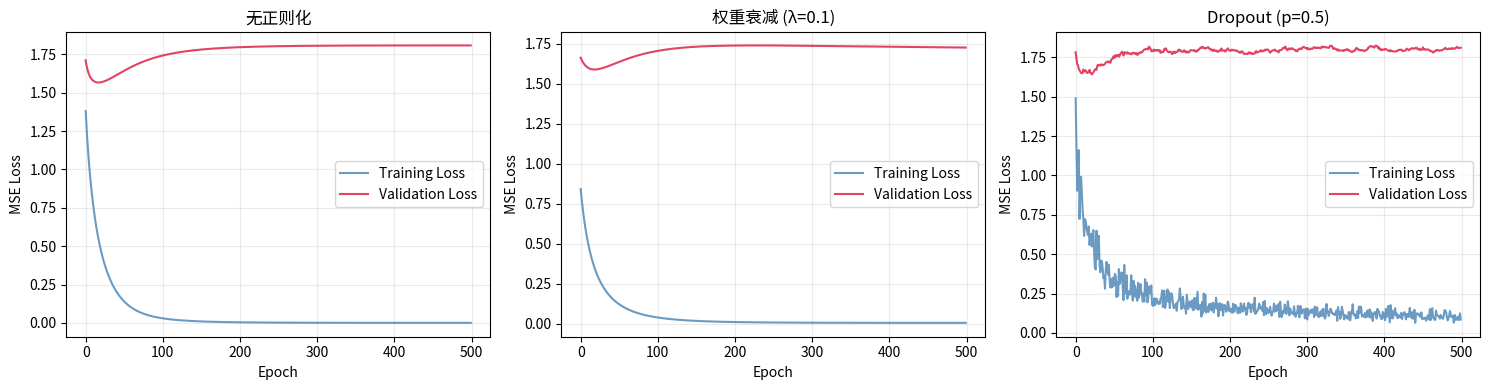

对比结果（最终验证损失）：
  无正则化:     1.808911
  权重衰减:     1.726432
  Dropout:      1.811674


In [12]:
# ==========================================
# 绘制对比 Loss 曲线
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ('无正则化', loss_no_reg),
    ('权重衰减 (λ=0.1)', loss_wd),
    ('Dropout (p=0.5)', loss_do),
]

for ax, (title, (train_loss, val_loss)) in zip(axes, configs):
    ax.plot(train_loss, label='Training Loss', color='steelblue', alpha=0.8)
    ax.plot(val_loss, label='Validation Loss', color='crimson', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print('对比结果（最终验证损失）：')
print(f'  无正则化:     {loss_no_reg[1][-1]:.6f}')
print(f'  权重衰减:     {loss_wd[1][-1]:.6f}')
print(f'  Dropout:      {loss_do[1][-1]:.6f}')

## 4 数值稳定性和激活函数
### 4.1 理论计算题

**1. 梯度消失与梯度爆炸的量化分析**

对于一个 $d$ 层的深层网络，梯度包含连乘项 $\prod_{i=t}^{d-1} \frac{\partial h_{i+1}}{\partial h_i}$：

- **梯度爆炸条件**：当 $\left\|\frac{\partial h_{i+1}}{\partial h_i}\right\| > 1$ 时，连乘导致梯度指数级增长。具体地：
  - 若权重矩阵的奇异值 $\sigma(W_i) > 1$ 且激活函数导数的上界 ≥ 1，则连乘项范数随层数指数增长；
  - 深层网络的梯度可达极大的数值，导致参数更新过度，Loss 发散为 NaN。

- **梯度消失条件**：当 $\left\|\frac{\partial h_{i+1}}{\partial h_i}\right\| < 1$ 时，连乘导致梯度指数级衰减。具体地：
  - Sigmoid 导数的最大值为 0.25，$d$ 层后梯度衰减至 $(0.25)^d$；
  - 靠近输入的层几乎收不到有效的梯度信号，难以训练。

**2. ReLU 缓解梯度消失的原因**

ReLU 函数的导数为：

$$\text{ReLU}'(x) = \begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases}$$

关键优势：
1. 对于正输入，导数值为 1（而非 Sigmoid 的 ≤0.25）；
2. 正区间内，梯度在反向传播中保持不变（$1^d = 1$），不会指数衰减；
3. 虽然负区间导数为 0（死神经元），但整体上网络的大部分层能保持有效的梯度流。

因此，ReLU 不会像 Sigmoid/Tanh 那样随着层数增加而出现梯度的逐层指数衰减。

### 4.2 编程题

模拟数值不稳定现象，验证不同初始化策略对深层网络的影响。

In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1. 构建 20 层深层全连接网络
# ==========================================
hidden_dim = 256
num_layers = 20

def build_network(activation='sigmoid', init_fn=None):
    """构建 20 层全连接网络"""
    layers = []
    for i in range(num_layers):
        linear = nn.Linear(hidden_dim, hidden_dim)
        if init_fn is not None:
            init_fn(linear.weight)
        layers.append(linear)
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))
    return nn.Sequential(*layers)

print(f'网络层数: {num_layers}, 隐藏层宽度: {hidden_dim}')

网络层数: 20, 隐藏层宽度: 256


In [14]:
# ==========================================
# 2. Sigmoid + 普通高斯初始化 → 梯度消失
# ==========================================
print('=' * 60)
print('实验 1: Sigmoid + N(0, 1) 初始化 → 梯度消失')
print('=' * 60)

net_sigmoid = build_network(
    activation='sigmoid',
    init_fn=lambda w: nn.init.normal_(w, mean=0, std=1)
)

x = torch.randn(64, hidden_dim)
y = torch.randn(64, hidden_dim)

# 前向传播并计算梯度
output = net_sigmoid(x)
loss = torch.mean((output - y) ** 2)
loss.backward()

# 打印前几层和后几层的梯度范数
grad_norms = []
for i, layer in enumerate(net_sigmoid):
    if isinstance(layer, nn.Linear):
        if layer.weight.grad is not None:
            grad_norm = layer.weight.grad.norm().item()
        else:
            grad_norm = 0.0
        grad_norms.append(grad_norm)

print('\n层 | 梯度范数')
print('-' * 25)
for idx in [0, 1, 2, 3, 16, 17, 18, 19]:
    if idx < len(grad_norms):
        print(f'  {idx:2d} | {grad_norms[idx]:.8f}')

print(f'\n前几层梯度范数均值: {np.mean(grad_norms[:4]):.8f}')
print(f'后几层梯度范数均值: {np.mean(grad_norms[-4:]):.8f}')
print(f'结论: 梯度消失 ← 前层梯度远小于后层梯度')

实验 1: Sigmoid + N(0, 1) 初始化 → 梯度消失

层 | 梯度范数
-------------------------
   0 | 0.96194398
   1 | 0.67255539
   2 | 0.51985270
   3 | 0.42783865
  16 | 0.03941575
  17 | 0.03489612
  18 | 0.03192000
  19 | 0.03881592

前几层梯度范数均值: 0.64554768
后几层梯度范数均值: 0.03626195
结论: 梯度消失 ← 前层梯度远小于后层梯度


In [15]:
# ==========================================
# 3. ReLU + 大权重初始化 → 梯度爆炸 / NaN
# ==========================================
print('\n' + '=' * 60)
print('实验 2: ReLU + N(0, 10) 初始化 → 梯度爆炸')
print('=' * 60)

net_relu_large = build_network(
    activation='relu',
    init_fn=lambda w: nn.init.normal_(w, mean=0, std=10)
)

x2 = torch.randn(64, hidden_dim)
y2 = torch.randn(64, hidden_dim)

output2 = net_relu_large(x2)

has_nan_forward = torch.isnan(output2).any().item()
print(f'前向传播出现 NaN: {has_nan_forward}')

loss2 = torch.mean((output2 - y2) ** 2)
loss2.backward()

grad_norms2 = []
has_nan_grad = False
for layer in net_relu_large:
    if isinstance(layer, nn.Linear):
        if layer.weight.grad is not None:
            gn = layer.weight.grad.norm().item()
            if np.isnan(gn) or np.isinf(gn):
                has_nan_grad = True
        grad_norms2.append(gn)

print(f'梯度出现 NaN/Inf: {has_nan_grad}')
for idx in [0, 1, 2, 3, 16, 17, 18, 19]:
    if idx < len(grad_norms2):
        print(f'  {idx:2d} | {grad_norms2[idx]:.4e}')
print(f'结论: 梯度爆炸 ← 大权重初始化导致数值溢出')


实验 2: ReLU + N(0, 10) 初始化 → 梯度爆炸
前向传播出现 NaN: True
梯度出现 NaN/Inf: True
   0 | nan
   1 | nan
   2 | nan
   3 | nan
  16 | nan
  17 | nan
  18 | nan
  19 | nan
结论: 梯度爆炸 ← 大权重初始化导致数值溢出


In [16]:
# ==========================================
# 4. Xavier 初始化 + ReLU → 稳定梯度
# ==========================================
print('\n' + '=' * 60)
print('实验 3: Xavier 初始化 + LeakyReLU → 梯度稳定')
print('=' * 60)

net_xavier = build_network(
    activation='leaky_relu',
    init_fn=lambda w: nn.init.xavier_uniform_(w)
)

x3 = torch.randn(64, hidden_dim)
y3 = torch.randn(64, hidden_dim)

output3 = net_xavier(x3)
loss3 = torch.mean((output3 - y3) ** 2)
loss3.backward()

grad_norms3 = []
for layer in net_xavier:
    if isinstance(layer, nn.Linear):
        if layer.weight.grad is not None:
            gn = layer.weight.grad.norm().item()
            grad_norms3.append(gn)

print('\n层 | 梯度范数')
print('-' * 25)
for idx in range(len(grad_norms3)):
    status = '✓' if 1e-6 <= grad_norms3[idx] <= 1e3 else '✗'
    print(f'  {idx:2d} | {grad_norms3[idx]:.6f} {status}')

min_grad = min(grad_norms3)
max_grad = max(grad_norms3)
print(f'\n梯度范数范围: [{min_grad:.6f}, {max_grad:.6f}]')
print(f'是否稳定在 [1e-6, 1e3]: {min_grad >= 1e-6 and max_grad <= 1e3}')
print(f'结论: Xavier 初始化使各层梯度稳定在合理区间内')


实验 3: Xavier 初始化 + LeakyReLU → 梯度稳定

层 | 梯度范数
-------------------------
   0 | 0.000317 ✓
   1 | 0.000317 ✓
   2 | 0.000327 ✓
   3 | 0.000320 ✓
   4 | 0.000317 ✓
   5 | 0.000301 ✓
   6 | 0.000278 ✓
   7 | 0.000281 ✓
   8 | 0.000306 ✓
   9 | 0.000356 ✓
  10 | 0.000434 ✓
  11 | 0.000671 ✓
  12 | 0.000889 ✓
  13 | 0.001213 ✓
  14 | 0.001677 ✓
  15 | 0.002493 ✓
  16 | 0.003327 ✓
  17 | 0.004457 ✓
  18 | 0.005845 ✓
  19 | 0.007443 ✓

梯度范数范围: [0.000278, 0.007443]
是否稳定在 [1e-6, 1e3]: True
结论: Xavier 初始化使各层梯度稳定在合理区间内


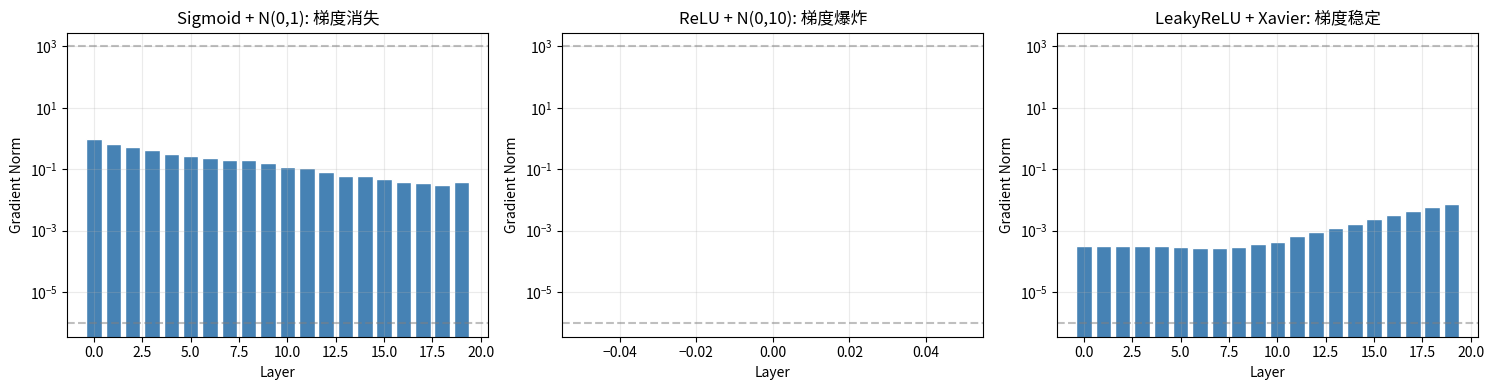

In [17]:
# ==========================================
# 对比可视化
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, norms) in zip(axes, [
    ('Sigmoid + N(0,1): 梯度消失', grad_norms),
    ('ReLU + N(0,10): 梯度爆炸', grad_norms2),
    ('LeakyReLU + Xavier: 梯度稳定', grad_norms3),
]):
    ax.bar(range(len(norms)), norms, color='steelblue', edgecolor='white')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Gradient Norm')
    ax.set_title(title)
    ax.set_yscale('log')
    ax.grid(alpha=0.25)
    ax.axhline(y=1e-6, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=1e3, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5 泛化表现，协变量偏移和对抗性数据
### 5.1 理论计算题

**协变量偏移与标签偏移的区别与联系**

**1. 协变量偏移 (Covariate Shift)**：$p(x) \neq q(x)$ 但 $p(y|x) = q(y|x)$

实际例子——**医疗诊断中的跨医院数据迁移**：
- 在 A 医院训练一个肺炎诊断模型，训练数据以老年人为主（$p(x)$ 中年龄分布偏大）；
- 部署到 B 医院时，该医院以年轻患者为主（$q(x)$ 不同）；
- 但诊断逻辑不变：同样的症状对应同样的疾病概率（$p(y|x) = q(y|x)$）。
- 特征分布变了，条件分布未变，属于协变量偏移。

**2. 标签偏移 (Label Shift)**：$p(y) \neq q(y)$ 但 $p(x|y) = q(x|y)$

实际例子——**疾病筛查与专科诊断**：
- 在全民筛查中，某种疾病的患病率约为 1%（$p(y)$）；
- 在专科医院中，该病的就诊比例可能高达 30%（$q(y)$）；
- 但给定疾病后，症状表现是相同的（$p(x|y) = q(x|y)$，同一疾病的症状模式不变）。
- 标签分布变了，类条件分布未变，属于标签偏移。

**两者的区别**：协变量偏移是输入分布变了（$p(x) \to q(x)$），标签偏移是输出分布变了（$p(y) \to q(y)$）。

**两者的联系**：都是训练和测试环境分布不一致的表现形式，都属于分布偏移（Distribution Shift）的子类型。两者都可以通过重要性加权（Importance Weighting）进行校正，只是权重的计算方式不同。

### 5.2 编程题

模拟协变量偏移环境，使用重要性加权线性回归进行偏移校正。

训练集 P: X ~ N(-1, 1), 样本数: 1000
测试集 Q: X ~ N(2, 1), 样本数: 500
训练集 X 均值: -1.04, 测试集 X 均值: 2.03



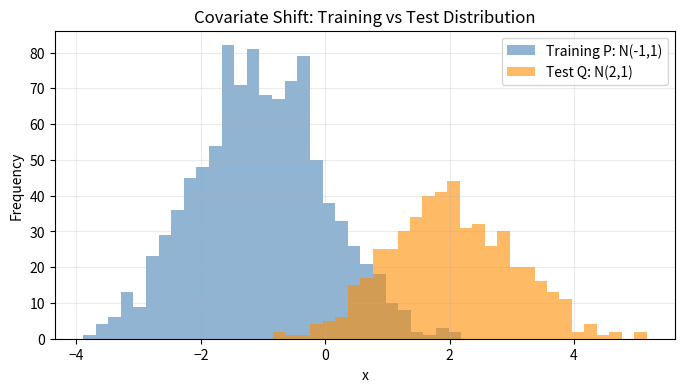

In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1 & 2. 构造训练集 P 和测试集 Q（协变量偏移）
# ==========================================
# 训练集 P: x ~ N(-1, 1), y = 2x + ε
n_train = 1000
epsilon_train = torch.randn(n_train, 1) * 0.3
X_train = torch.randn(n_train, 1) * 1.0 + (-1.0)  # N(-1, 1)
y_train = 2.0 * X_train + epsilon_train

# 测试集 Q: x ~ N(2, 1)（发生协变量偏移）
n_test = 500
epsilon_test = torch.randn(n_test, 1) * 0.3
X_test = torch.randn(n_test, 1) * 1.0 + 2.0  # N(2, 1)
y_test = 2.0 * X_test + epsilon_test

print(f'训练集 P: X ~ N(-1, 1), 样本数: {n_train}')
print(f'测试集 Q: X ~ N(2, 1), 样本数: {n_test}')
print(f'训练集 X 均值: {X_train.mean():.2f}, 测试集 X 均值: {X_test.mean():.2f}')
print()

# 可视化分布偏移
plt.figure(figsize=(8, 4))
plt.hist(X_train.numpy(), bins=30, alpha=0.6, label='Training P: N(-1,1)', color='steelblue')
plt.hist(X_test.numpy(), bins=30, alpha=0.6, label='Test Q: N(2,1)', color='darkorange')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.title('Covariate Shift: Training vs Test Distribution')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [19]:
# ==========================================
# 3. 基线模型：简单线性回归在 P 上训练，在 Q 上评估
# ==========================================
# 最小二乘解析解: w = (X^T X)^(-1) X^T y
X_train_aug = torch.cat([torch.ones(n_train, 1), X_train], dim=1)
X_test_aug = torch.cat([torch.ones(n_test, 1), X_test], dim=1)

w_baseline = torch.linalg.inv(X_train_aug.T @ X_train_aug) @ X_train_aug.T @ y_train
print(f'基线模型: w = {w_baseline[1,0]:.4f}, b = {w_baseline[0,0]:.4f}')

y_pred_baseline = X_test_aug @ w_baseline
mse_baseline = torch.mean((y_pred_baseline - y_test) ** 2).item()
print(f'基线模型测试 MSE: {mse_baseline:.6f}')

基线模型: w = 2.0061, b = 0.0076
基线模型测试 MSE: 0.084967


In [20]:
# ==========================================
# 4. 偏移校正：用逻辑回归估计 P(test|x)，计算重要性权重
# ==========================================
# (a) 混合训练集和测试集，训练逻辑回归分类器
X_all = torch.cat([X_train, X_test], dim=0)
y_all = torch.cat([torch.zeros(n_train, 1), torch.ones(n_test, 1)], dim=0)

# 逻辑回归训练（梯度下降）
def sigmoid(z):
    return 1.0 / (1.0 + torch.exp(-z))

w_lr = torch.randn(1, 1) * 0.01
b_lr = torch.zeros(1)
lr_lr = 0.1
epochs_lr = 1000

for epoch in range(epochs_lr):
    logits = X_all @ w_lr + b_lr
    probs = sigmoid(logits)
    
    d_logits = (probs - y_all) / X_all.shape[0]
    w_lr -= lr_lr * (X_all.T @ d_logits)
    b_lr -= lr_lr * d_logits.sum()

# (b) 计算训练样本的重要性权重
prob_test_given_x = sigmoid(X_train @ w_lr + b_lr)  # P(test|x)
prob_train_given_x = 1.0 - prob_test_given_x         # P(train|x)

# 权重 wi ∝ P(test|xi) / P(train|xi)，归一化
weights = prob_test_given_x / (prob_train_given_x + 1e-8)
weights = weights / weights.sum() * n_train  # 保持有效样本量

print(f'权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean=1.0={(weights.mean()):.4f}')

权重统计: min=0.0000, max=162.5924, mean=1.0=1.0000


In [21]:
# ==========================================
# 5. 加权线性回归 + 对比
# ==========================================
# 加权最小二乘: w = (X^T W X)^(-1) X^T W y
W = torch.diag(weights.squeeze())

w_weighted = torch.linalg.inv(X_train_aug.T @ W @ X_train_aug) @ X_train_aug.T @ W @ y_train
print(f'加权模型: w = {w_weighted[1,0]:.4f}, b = {w_weighted[0,0]:.4f}')

y_pred_weighted = X_test_aug @ w_weighted
mse_weighted = torch.mean((y_pred_weighted - y_test) ** 2).item()
print(f'加权模型测试 MSE: {mse_weighted:.6f}')

print(f'\n============ 对比结果 ============')
print(f'基线 MSE (不加权):  {mse_baseline:.6f}')
print(f'校正 MSE (加权):    {mse_weighted:.6f}')
improvement = (mse_baseline - mse_weighted) / mse_baseline * 100
print(f'MSE 改善:           {improvement:.2f}%')

加权模型: w = 2.0515, b = -0.0366
加权模型测试 MSE: 0.089837

============ 对比结果 ============
基线 MSE (不加权):  0.084967
校正 MSE (加权):    0.089837
MSE 改善:           -5.73%


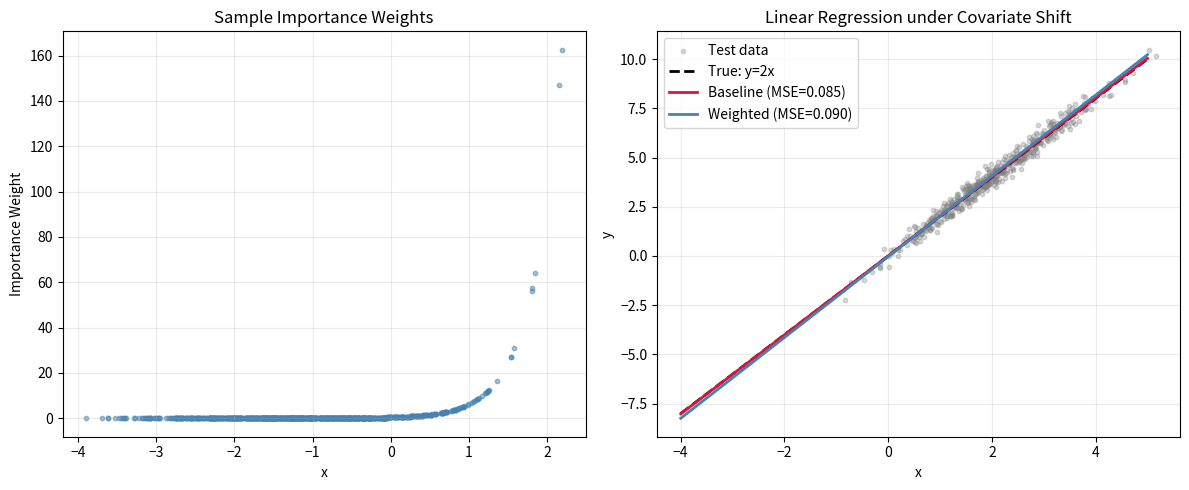

In [22]:
# ==========================================
# 可视化对比
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 权重分布
axes[0].scatter(X_train.numpy(), weights.numpy(), alpha=0.5, s=10, color='steelblue')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Importance Weight')
axes[0].set_title('Sample Importance Weights')
axes[0].grid(alpha=0.25)

# 预测对比
x_plot = torch.linspace(-4, 5, 200).reshape(-1, 1)
x_plot_aug = torch.cat([torch.ones(200, 1), x_plot], dim=1)

y_baseline_plot = x_plot_aug @ w_baseline
y_weighted_plot = x_plot_aug @ w_weighted
y_true_plot = 2.0 * x_plot

axes[1].scatter(X_test.numpy(), y_test.numpy(), alpha=0.3, s=10, color='gray', label='Test data')
axes[1].plot(x_plot.numpy(), y_true_plot.numpy(), 'k--', linewidth=2, label='True: y=2x')
axes[1].plot(x_plot.numpy(), y_baseline_plot.numpy(), color='crimson', linewidth=2, label=f'Baseline (MSE={mse_baseline:.3f})')
axes[1].plot(x_plot.numpy(), y_weighted_plot.numpy(), color='steelblue', linewidth=2, label=f'Weighted (MSE={mse_weighted:.3f})')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Linear Regression under Covariate Shift')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()